In [2]:
import shap
import joblib
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')
from data import get_processed_data, CONTINUOUS_FEATURES, CATEGORICAL_FEATURES

model = joblib.load('../models/best_model.pkl')
X_train, X_test, y_train, y_test = get_processed_data()

In [ ]:
preprocessor = model.named_steps['preprocessor']
preprocessor.fit(X_train)

cat_feature_names = (preprocessor
                    .named_transformers_['categorical']
                    .named_steps['encoder']
                    .get_feature_names_out(CATEGORICAL_FEATURES)
                    .tolist())

feature_names = CONTINUOUS_FEATURES + cat_feature_names
print(f"Total features after encoding: {len(feature_names)}")

Total features after encoding: 28


In [17]:
X_test_transformed = preprocessor.transform(X_test)
classifier = model.named_steps['classifier']

explainer = shap.LinearExplainer(classifier, X_test_transformed)
shap_values = explainer(X_test_transformed)

shap_values.feature_names = feature_names

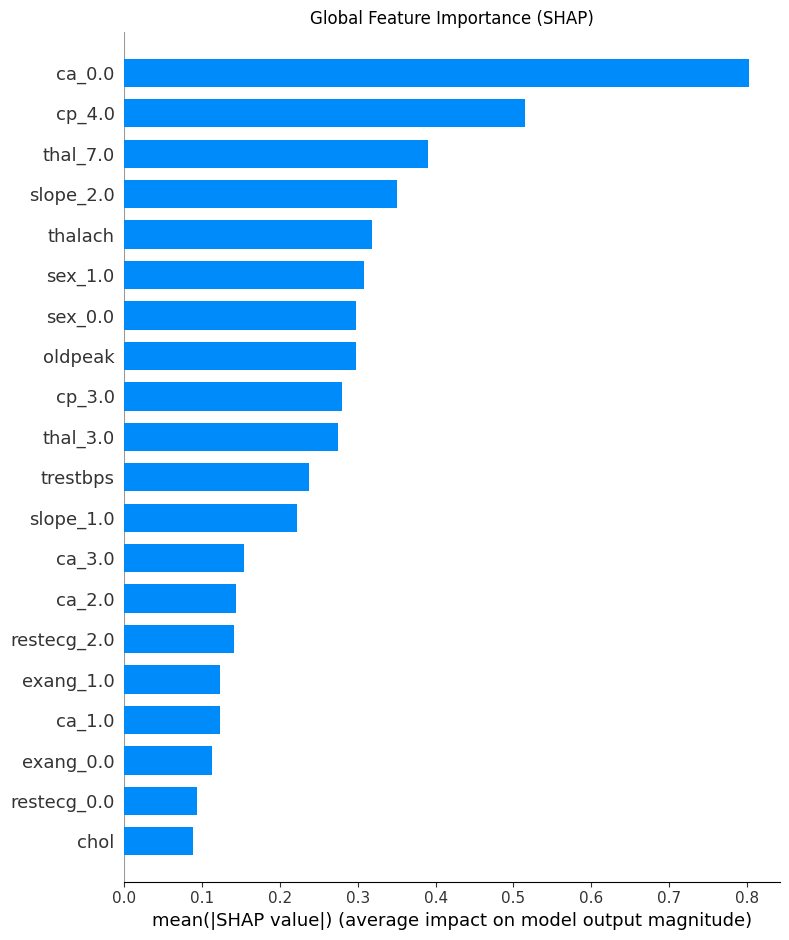

In [21]:
plt.figure()
shap.summary_plot(shap_values, X_test_transformed, 
                  feature_names=feature_names,
                  plot_type='bar', show=False)

plt.title('Global Feature Importance (SHAP)')
plt.tight_layout()
plt.savefig('../data/raw/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

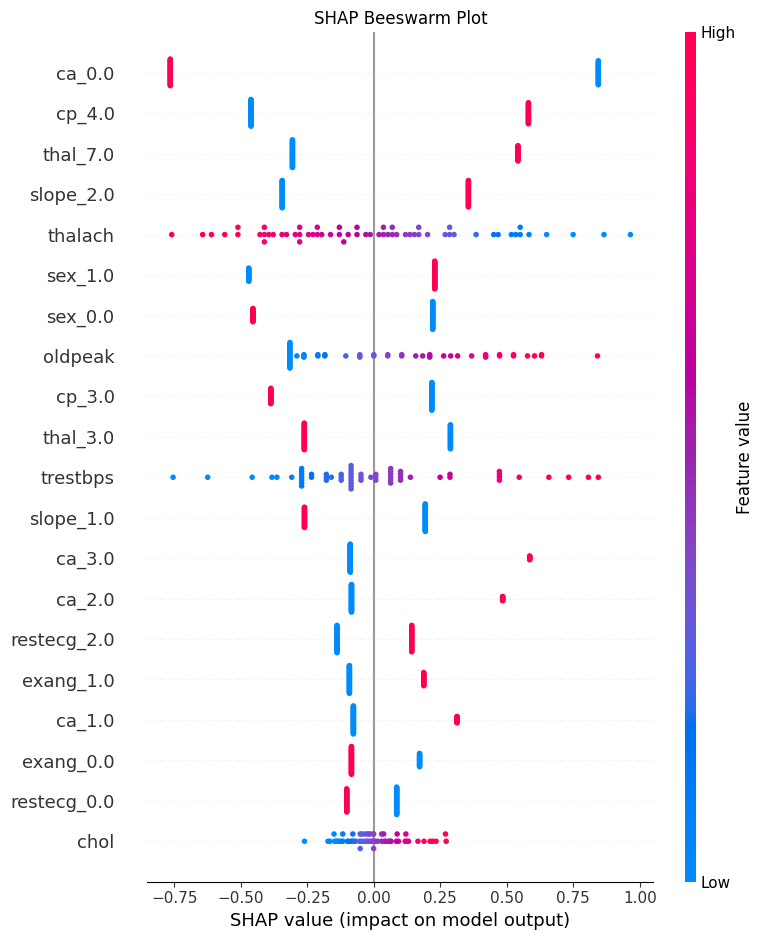

In [22]:
plt.figure()
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=feature_names, show=False)
plt.title('SHAP Beeswarm Plot')
plt.tight_layout()
plt.savefig('../data/raw/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

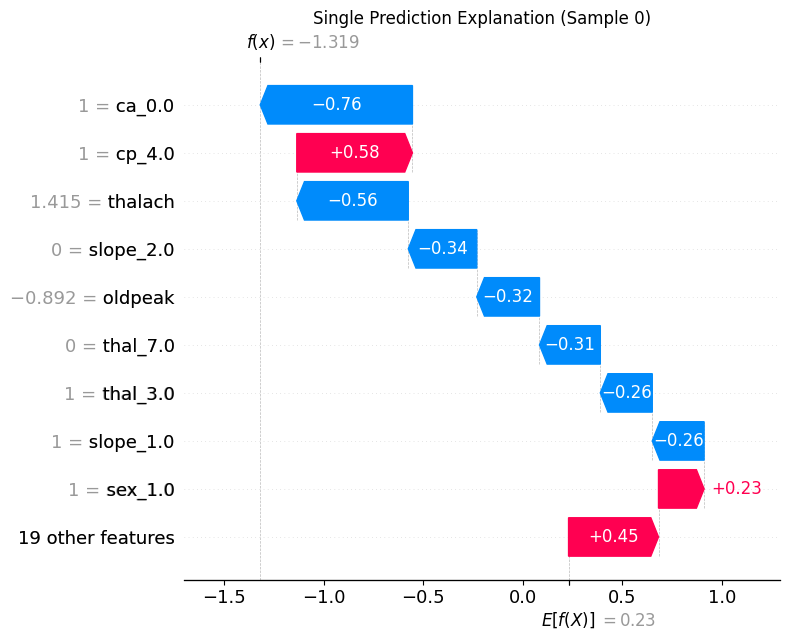

Actual label: No Disease
Predicted:    No Disease


In [38]:
sample_idx = 0
shap.waterfall_plot(shap_values[sample_idx], show=False)
plt.title(f'Single Prediction Explanation (Sample {sample_idx})')
plt.tight_layout()
plt.savefig('../data/raw/shap_single.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Actual label: {'Disease' if y_test[sample_idx] == 1 else 'No Disease'}")
print(f"Predicted:    {'Disease' if model.predict(X_test[sample_idx:sample_idx+1])[0] == 1 else 'No Disease'}")